# Regime Switching and MS-GARCH Parameter Analysis

This notebook analyzes regime switching and MS-GARCH parameters to understand:
- How often we are in each regime
- Parameter differences between regimes
- Transition dynamics and regime persistence
- Volatility patterns across regimes

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load the data
rs_params = pd.read_csv('data/output/regime_switching_parameters.csv')
ms_garch = pd.read_csv('data/output/ms_garch_parameters.csv')

# Convert date columns to datetime
rs_params['date'] = pd.to_datetime(rs_params['date'])
ms_garch['date'] = pd.to_datetime(ms_garch['date'])

print('Regime Switching Parameters:')
print(f'Shape: {rs_params.shape}')
print(f'Date range: {rs_params["date"].min()} to {rs_params["date"].max()}')
print(f'Number of companies: {rs_params["gvkey"].nunique()}')
print()
print('MS-GARCH Parameters:')
print(f'Shape: {ms_garch.shape}')
print(f'Date range: {ms_garch["date"].min()} to {ms_garch["date"].max()}')
print(f'Number of companies: {ms_garch["gvkey"].nunique()}')

Regime Switching Parameters:
Shape: (2424, 14)
Date range: 2018-11-30 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34

MS-GARCH Parameters:
Shape: (2424, 18)
Date range: 2018-11-30 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34


In [3]:
# Display first few rows of each dataset
print('Regime Switching Parameters - First 5 rows:')
display(rs_params.head())

print('\nMS-GARCH Parameters - First 5 rows:')
display(ms_garch.head())

Regime Switching Parameters - First 5 rows:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
0,14447,2019-01-31,0.000652,0.000043,0.008024,0.014120,4.830451,4.855990,0.994572,0.005428,0.003241,0.996759,0.0,0.0
1,14447,2019-02-28,0.000638,0.000133,0.008054,0.014043,5.039440,4.943288,0.994207,0.005793,0.003765,0.996235,0.0,0.0
2,14447,2019-03-29,0.000815,-0.000053,0.008383,0.014211,4.799247,5.466790,0.992965,0.007035,0.006917,0.993083,0.0,0.0
3,14447,2019-04-30,0.000897,-0.000194,0.008908,0.014261,4.352646,6.167751,0.993611,0.006389,0.007524,0.992476,0.0,0.0
4,14447,2019-05-31,0.001009,-0.000144,0.008570,0.014302,4.993836,6.052645,0.990239,0.009761,0.008887,0.991113,0.0,0.0



MS-GARCH Parameters - First 5 rows:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
0,14447,2019-01-31,7.351422e-08,0.027217,0.971783,0.000001,0.26136,0.62194,0.000282,0.001101,0.955359,0.950144,29.551691,2.817318,-7678.537706,15381.075413,15442.741817,1260
1,14447,2019-02-28,7.351424e-08,0.027217,0.971783,0.000001,0.26136,0.62194,0.000282,0.001101,0.955359,0.950144,29.551686,2.817318,-7693.603201,15411.206402,15472.872806,1260
2,14447,2019-03-29,7.351424e-08,0.027217,0.971783,0.000001,0.26136,0.62194,0.000282,0.001101,0.955359,0.950144,29.551686,2.817318,-7702.801821,15429.603643,15491.270047,1260
3,14447,2019-04-30,7.351424e-08,0.027217,0.971783,0.000001,0.26136,0.62194,0.000282,0.001101,0.955359,0.950144,29.551686,2.817318,-7717.996215,15459.992429,15521.658833,1260
4,14447,2019-05-31,7.351424e-08,0.027217,0.971783,0.000001,0.26136,0.62194,0.000282,0.001101,0.955359,0.950144,29.551686,2.817318,-7730.944954,15485.889907,15547.556311,1260


In [4]:
# Summary statistics
print('Regime Switching - Summary Statistics:')
display(rs_params.describe())

print('\nMS-GARCH - Summary Statistics:')
display(ms_garch.describe())

Regime Switching - Summary Statistics:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
count,2424.000000,2424,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.0,2424.0
mean,97083.097772,2022-01-24 12:05:56.435643,-0.000106,-0.000272,0.009485,0.020626,6.786723,8.813667,0.940432,0.059568,0.055999,0.944001,0.0,0.0
min,14447.000000,2018-11-30 00:00:00,-0.016085,-0.005262,0.000831,0.001942,2.001000,2.001000,0.010000,0.001000,0.001000,0.240518,0.0,0.0
25%,17452.000000,2020-07-31 00:00:00,0.000041,-0.000547,0.004574,0.011458,3.474075,2.505700,0.977754,0.003884,0.009009,0.954836,0.0,0.0
50%,100581.000000,2022-01-31 00:00:00,0.000210,-0.000144,0.006901,0.016519,4.105705,3.559163,0.991643,0.008357,0.024492,0.975508,0.0,0.0
75%,132740.000000,2023-07-31 00:00:00,0.000565,0.000088,0.009713,0.024903,5.059443,5.325534,0.996116,0.022246,0.045164,0.990991,0.0,0.0
max,241637.000000,2024-12-31 00:00:00,0.002127,0.005390,0.044399,0.044817,405.428793,405.428793,0.999000,0.990000,0.759482,0.999000,0.0,0.0
std,79526.428524,NaN,0.002279,0.000869,0.009842,0.013011,25.186310,42.946824,0.190587,0.190587,0.114780,0.114780,0.0,0.0



MS-GARCH - Summary Statistics:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
count,2424.000000,2424,2.424000e+03,2.424000e+03,2424.000000,2.424000e+03,2.424000e+03,2.424000e+03,2.424000e+03,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.000000,2424.0
mean,97083.097772,2022-01-24 12:05:56.435643,2.214129e-04,7.173507e-02,0.621717,4.274121e-03,1.179411e-01,6.131028e-01,-1.939127e-03,0.000913,0.839137,0.904861,25.130068,3.483294,-6991.382642,14006.765284,14068.431688,1260.0
min,14447.000000,2018-11-30 00:00:00,4.876208e-13,1.917716e-22,0.000029,1.033616e-10,9.504752e-10,1.012906e-09,-7.698151e-02,-0.001715,0.000001,0.408592,2.000000,2.000023,-8918.409306,9340.933360,9402.599764,1260.0
25%,17452.000000,2020-07-31 00:00:00,6.835027e-08,1.134520e-03,0.068818,1.035921e-06,6.756660e-03,4.445164e-01,-1.920144e-04,0.000103,0.854794,0.877811,2.439292,2.148955,-7510.471154,13217.482225,13279.148629,1260.0
50%,100581.000000,2022-01-31 00:00:00,3.098412e-07,4.699497e-02,0.883868,4.624808e-06,7.031282e-02,7.684803e-01,1.924280e-09,0.000440,0.912204,0.956703,5.757486,3.053162,-7171.533765,14367.067530,14428.733934,1260.0
75%,132740.000000,2023-07-31 00:00:00,1.461714e-06,7.499742e-02,0.952005,5.003897e-05,1.607702e-01,8.986643e-01,6.489436e-05,0.000708,0.982344,0.988055,17.708953,4.815144,-6596.741113,15044.942309,15106.608713,1260.0
max,241637.000000,2024-12-31 00:00:00,3.246371e-02,6.603978e-01,0.998003,7.233117e-01,8.323758e-01,9.987784e-01,1.699173e-03,0.065427,0.999394,0.999975,1339.063179,17.329724,-4658.466680,17860.818612,17922.485016,1260.0
std,79526.428524,NaN,1.317986e-03,1.015420e-01,0.404173,2.347525e-02,1.564120e-01,3.425724e-01,1.174574e-02,0.004038,0.226753,0.136204,104.702119,1.536598,890.133079,1780.266159,1780.266159,0.0


## 3. Regime Frequency Analysis

Calculate how often we are in each regime using steady-state probabilities from the transition matrix.

In [5]:
def calculate_steady_state_probabilities(p00, p11):
    """
    Calculate steady-state probabilities for a 2-state Markov chain.
    
    For a transition matrix:
    P = [[p00, p01],
         [p10, p11]]
    
    Steady state: pi = pi * P
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    """
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    return pi_0, pi_1

# Calculate steady-state probabilities for regime switching
rs_params['steady_state_regime_0'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[0],
    axis=1
)
rs_params['steady_state_regime_1'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[1],
    axis=1
)

# Calculate for MS-GARCH
ms_garch['steady_state_regime_0'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[0],
    axis=1
)
ms_garch['steady_state_regime_1'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[1],
    axis=1
)

print('Regime Switching - Average Time in Each Regime:')
print(f'Regime 0: {rs_params["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {rs_params["steady_state_regime_1"].mean():.2%}')

print('\nMS-GARCH - Average Time in Each Regime:')
print(f'Regime 0: {ms_garch["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {ms_garch["steady_state_regime_1"].mean():.2%}')

Regime Switching - Average Time in Each Regime:
Regime 0: 66.68%
Regime 1: 33.32%

MS-GARCH - Average Time in Each Regime:
Regime 0: 46.72%
Regime 1: 53.28%


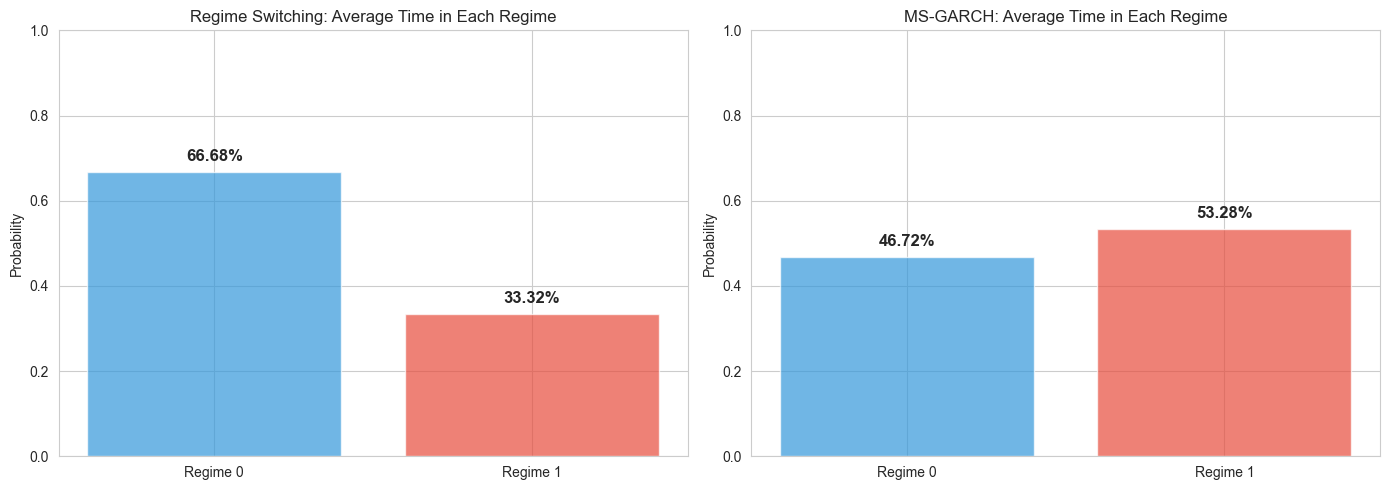

In [6]:
# Visualize regime frequencies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_regime_freq = rs_params[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].bar(['Regime 0', 'Regime 1'], rs_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Average Time in Each Regime')
axes[0].set_ylim([0, 1])
for i, v in enumerate(rs_regime_freq):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# MS-GARCH
ms_regime_freq = ms_garch[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].bar(['Regime 0', 'Regime 1'], ms_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Probability')
axes[1].set_title('MS-GARCH: Average Time in Each Regime')
axes[1].set_ylim([0, 1])
for i, v in enumerate(ms_regime_freq):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

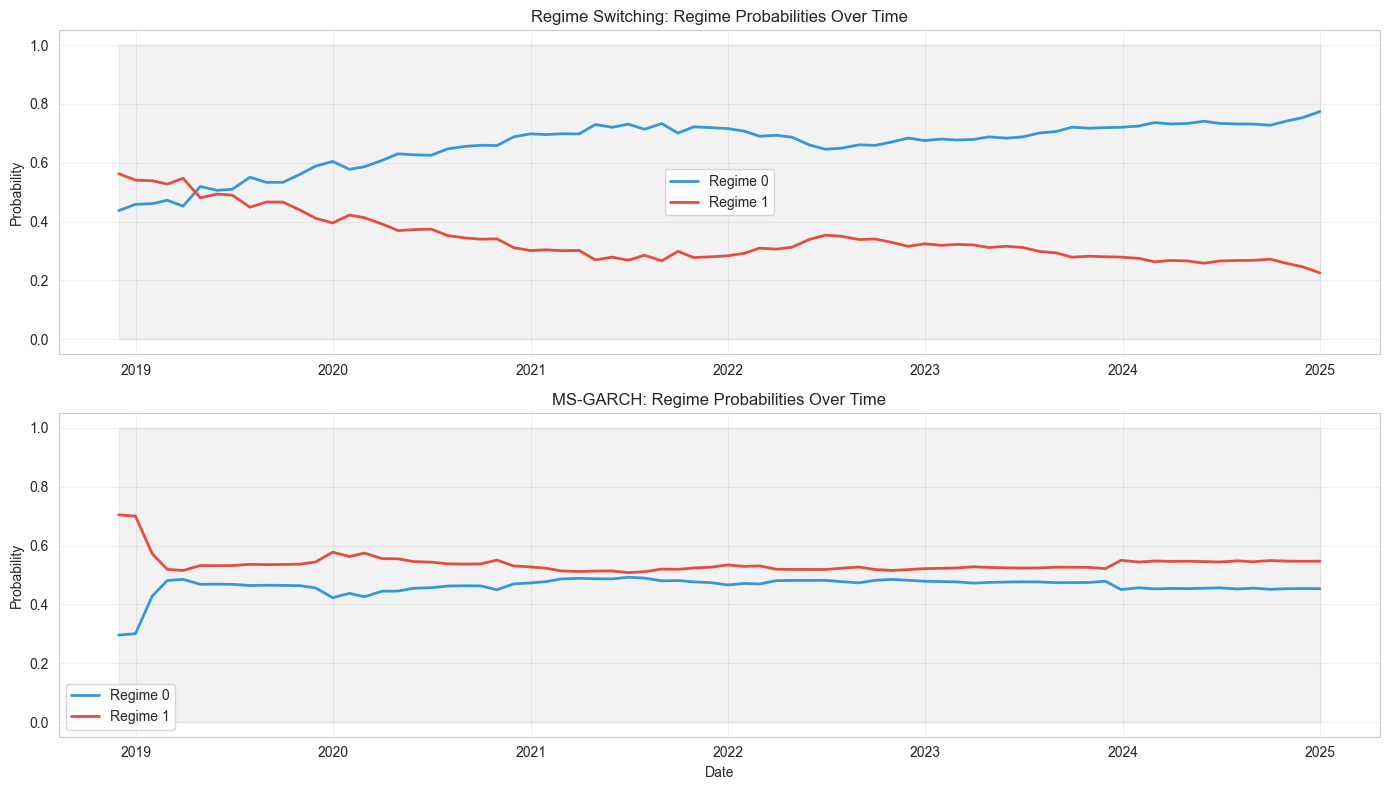

In [7]:
# Distribution of regime frequencies across time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Regime Switching over time
rs_time = rs_params.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].plot(rs_time.index, rs_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_time.index, rs_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_time.index, 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH over time
ms_time = ms_garch.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].plot(ms_time.index, ms_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[1].plot(ms_time.index, ms_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[1].fill_between(ms_time.index, 0, 1, alpha=0.1, color='gray')
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Probabilities Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Regime Duration Analysis

Expected duration in regime i: 1 / (1 - p_ii)

In [8]:
# Calculate expected durations
rs_params['duration_regime_0'] = 1 / (1 - rs_params['transition_prob_00'])
rs_params['duration_regime_1'] = 1 / (1 - rs_params['transition_prob_11'])

ms_garch['duration_regime_0'] = 1 / (1 - ms_garch['p00'])
ms_garch['duration_regime_1'] = 1 / (1 - ms_garch['p11'])

print('Regime Switching - Expected Duration (in periods):')
print(f'Regime 0: {rs_params["duration_regime_0"].mean():.2f} ± {rs_params["duration_regime_0"].std():.2f}')
print(f'Regime 1: {rs_params["duration_regime_1"].mean():.2f} ± {rs_params["duration_regime_1"].std():.2f}')

print('\nMS-GARCH - Expected Duration (in periods):')
print(f'Regime 0: {ms_garch["duration_regime_0"].mean():.2f} ± {ms_garch["duration_regime_0"].std():.2f}')
print(f'Regime 1: {ms_garch["duration_regime_1"].mean():.2f} ± {ms_garch["duration_regime_1"].std():.2f}')

Regime Switching - Expected Duration (in periods):
Regime 0: 203.26 ± 235.89
Regime 1: 144.67 ± 258.56

MS-GARCH - Expected Duration (in periods):
Regime 0: 60.43 ± 137.49
Regime 1: 113.92 ± 904.97


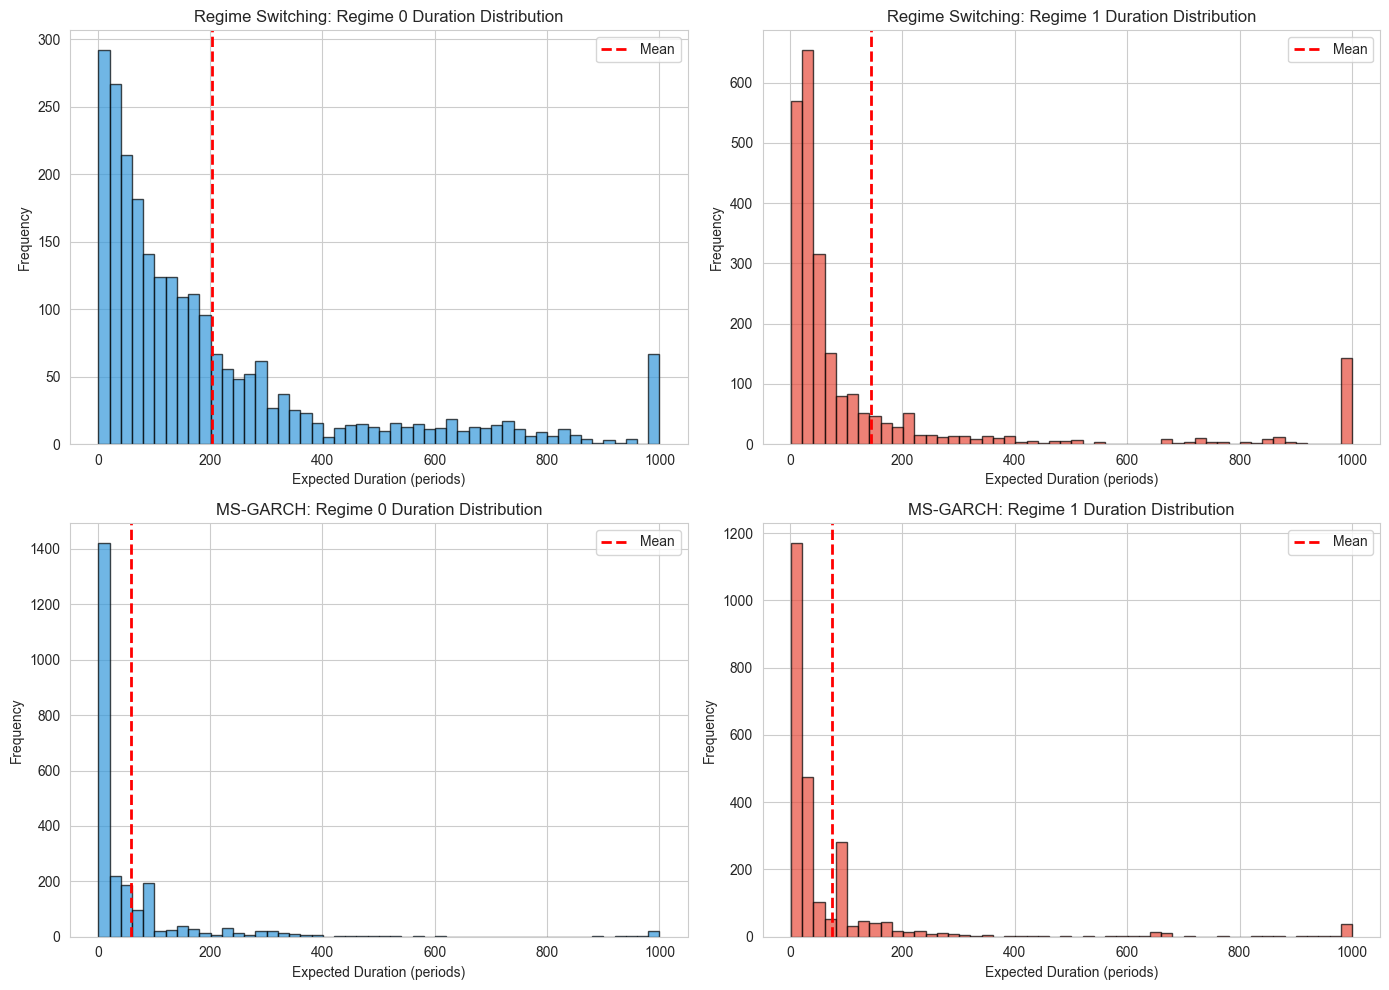


Note: Durations capped at 1000 periods for visualization
Infinite/extreme durations filtered:
  RS Regime 0: 0
  RS Regime 1: 0
  MS-GARCH Regime 0: 17
  MS-GARCH Regime 1: 39


In [9]:
# Visualize duration distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filter out infinite values and cap durations for better visualization
def filter_duration(series, max_duration=1000):
    """Filter out infinite values and cap at max_duration for visualization"""
    return series.replace([np.inf, -np.inf], np.nan).clip(upper=max_duration)

# Regime Switching - Regime 0
rs_dur_0_filtered = filter_duration(rs_params['duration_regime_0'])
axes[0, 0].hist(rs_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Expected Duration (periods)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: Regime 0 Duration Distribution')
axes[0, 0].legend()

# Regime Switching - Regime 1
rs_dur_1_filtered = filter_duration(rs_params['duration_regime_1'])
axes[0, 1].hist(rs_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Expected Duration (periods)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: Regime 1 Duration Distribution')
axes[0, 1].legend()

# MS-GARCH - Regime 0
ms_dur_0_filtered = filter_duration(ms_garch['duration_regime_0'])
axes[1, 0].hist(ms_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Expected Duration (periods)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: Regime 0 Duration Distribution')
axes[1, 0].legend()

# MS-GARCH - Regime 1
ms_dur_1_filtered = filter_duration(ms_garch['duration_regime_1'])
axes[1, 1].hist(ms_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Expected Duration (periods)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: Regime 1 Duration Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print info about filtered values
print(f"\nNote: Durations capped at 1000 periods for visualization")
print(f"Infinite/extreme durations filtered:")
print(f"  RS Regime 0: {rs_params['duration_regime_0'].isna().sum() + (rs_params['duration_regime_0'] > 1000).sum()}")
print(f"  RS Regime 1: {rs_params['duration_regime_1'].isna().sum() + (rs_params['duration_regime_1'] > 1000).sum()}")
print(f"  MS-GARCH Regime 0: {ms_garch['duration_regime_0'].isna().sum() + (ms_garch['duration_regime_0'] > 1000).sum()}")
print(f"  MS-GARCH Regime 1: {ms_garch['duration_regime_1'].isna().sum() + (ms_garch['duration_regime_1'] > 1000).sum()}")

## 5. Parameter Comparison Between Regimes

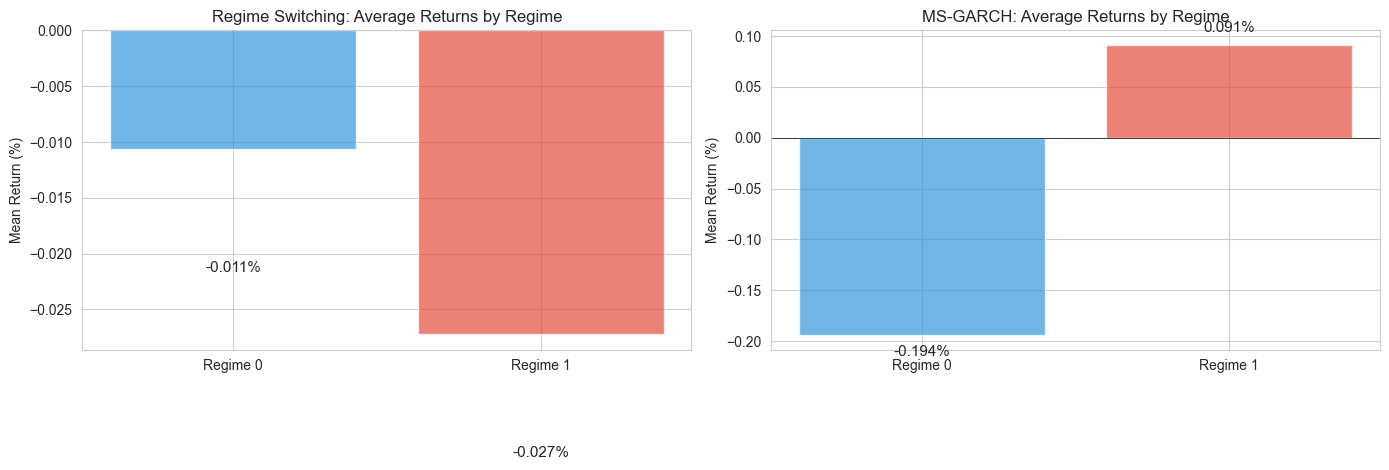

In [10]:
# Compare mean returns between regimes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_means = rs_params[['regime_0_mean', 'regime_1_mean']].mean() * 100  # Convert to percentage
axes[0].bar(['Regime 0', 'Regime 1'], rs_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Mean Return (%)')
axes[0].set_title('Regime Switching: Average Returns by Regime')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(rs_means):
    axes[0].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

# MS-GARCH
ms_means = ms_garch[['mu_0', 'mu_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('MS-GARCH: Average Returns by Regime')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(ms_means):
    axes[1].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
# Detailed parameter comparison table
print('='*80)
print('REGIME SWITCHING MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_rs = pd.DataFrame({
    'Parameter': ['Mean Return', 'Volatility', 'Degrees of Freedom (nu)'],
    'Regime 0': [
        f"{rs_params['regime_0_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_0_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_0_nu'].mean():.2f}"
    ],
    'Regime 1': [
        f"{rs_params['regime_1_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_1_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean():.2f}"
    ],
    'Difference': [
        f"{(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%",
        f"{(rs_params['regime_1_vol'].mean() - rs_params['regime_0_vol'].mean())*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean() - rs_params['regime_0_nu'].mean():.2f}"
    ]
})
display(comparison_rs)

print('\n' + '='*80)
print('MS-GARCH MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_ms = pd.DataFrame({
    'Parameter': ['Mean Return', 'Degrees of Freedom (nu)', 'Omega', 'Alpha', 'Beta'],
    'Regime 0': [
        f"{ms_garch['mu_0'].mean()*100:.4f}%",
        f"{ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_0'].mean():.6f}",
        f"{ms_garch['alpha_0'].mean():.6f}",
        f"{ms_garch['beta_0'].mean():.6f}"
    ],
    'Regime 1': [
        f"{ms_garch['mu_1'].mean()*100:.4f}%",
        f"{ms_garch['nu_1'].mean():.2f}",
        f"{ms_garch['omega_1'].mean():.6f}",
        f"{ms_garch['alpha_1'].mean():.6f}",
        f"{ms_garch['beta_1'].mean():.6f}"
    ],
    'Ratio (R1/R0)': [
        f"{ms_garch['mu_1'].mean() / ms_garch['mu_0'].mean() if ms_garch['mu_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['nu_1'].mean() / ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_1'].mean() / ms_garch['omega_0'].mean() if ms_garch['omega_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['alpha_1'].mean() / ms_garch['alpha_0'].mean() if ms_garch['alpha_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['beta_1'].mean() / ms_garch['beta_0'].mean():.2f}"
    ]
})
display(comparison_ms)

REGIME SWITCHING MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Difference
0,Mean Return,-0.0106%,-0.0272%,-0.0166%
1,Volatility,0.9485%,2.0626%,1.1142%
2,Degrees of Freedom (nu),6.79,8.81,2.03



MS-GARCH MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Ratio (R1/R0)
0,Mean Return,-0.1939%,0.0913%,-0.47
1,Degrees of Freedom (nu),25.13,3.48,0.14
2,Omega,0.000221,0.004274,19.30
3,Alpha,0.071735,0.117941,1.64
4,Beta,0.621717,0.613103,0.99


## 6. Volatility Analysis by Regime

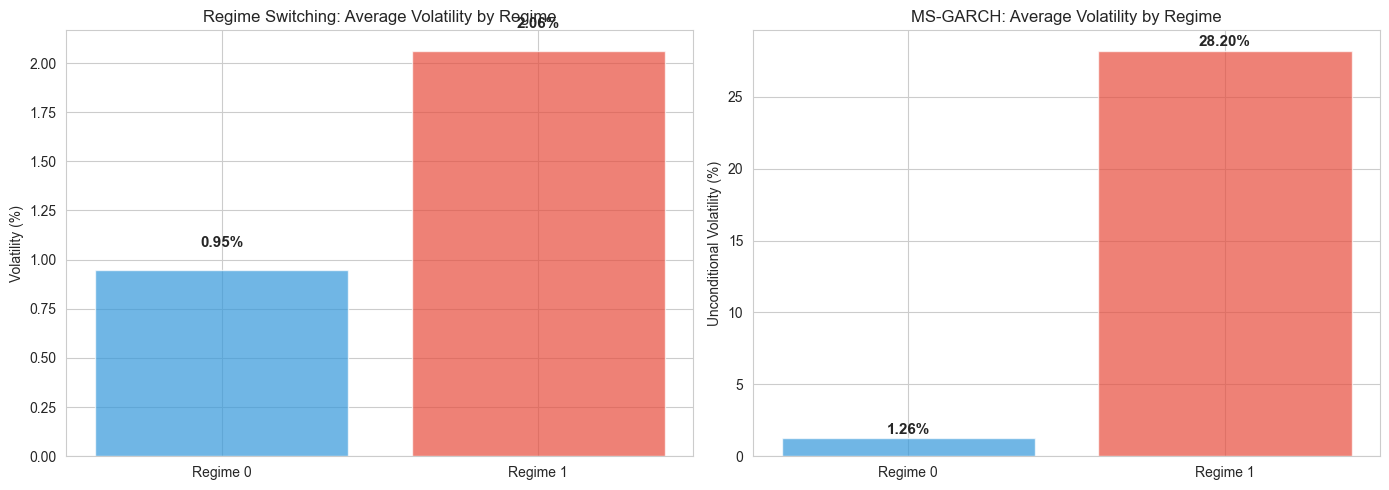

Regime Switching: Volatility Ratio (Regime 1 / Regime 0) = 2.17x
MS-GARCH: Volatility Ratio (Regime 1 / Regime 0) = 22.40x


In [12]:
# Volatility comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_vols = rs_params[['regime_0_vol', 'regime_1_vol']].mean() * 100
axes[0].bar(['Regime 0', 'Regime 1'], rs_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('Regime Switching: Average Volatility by Regime')
for i, v in enumerate(rs_vols):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MS-GARCH - Calculate implied volatility from GARCH parameters
# Unconditional variance = omega / (1 - alpha - beta)
ms_garch['uncond_vol_0'] = np.sqrt(ms_garch['omega_0'] / (1 - ms_garch['alpha_0'] - ms_garch['beta_0']))
ms_garch['uncond_vol_1'] = np.sqrt(ms_garch['omega_1'] / (1 - ms_garch['alpha_1'] - ms_garch['beta_1']))

ms_vols = ms_garch[['uncond_vol_0', 'uncond_vol_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Unconditional Volatility (%)')
axes[1].set_title('MS-GARCH: Average Volatility by Regime')
for i, v in enumerate(ms_vols):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Regime Switching: Volatility Ratio (Regime 1 / Regime 0) = {rs_vols['regime_1_vol'] / rs_vols['regime_0_vol']:.2f}x")
print(f"MS-GARCH: Volatility Ratio (Regime 1 / Regime 0) = {ms_vols['uncond_vol_1'] / ms_vols['uncond_vol_0']:.2f}x")

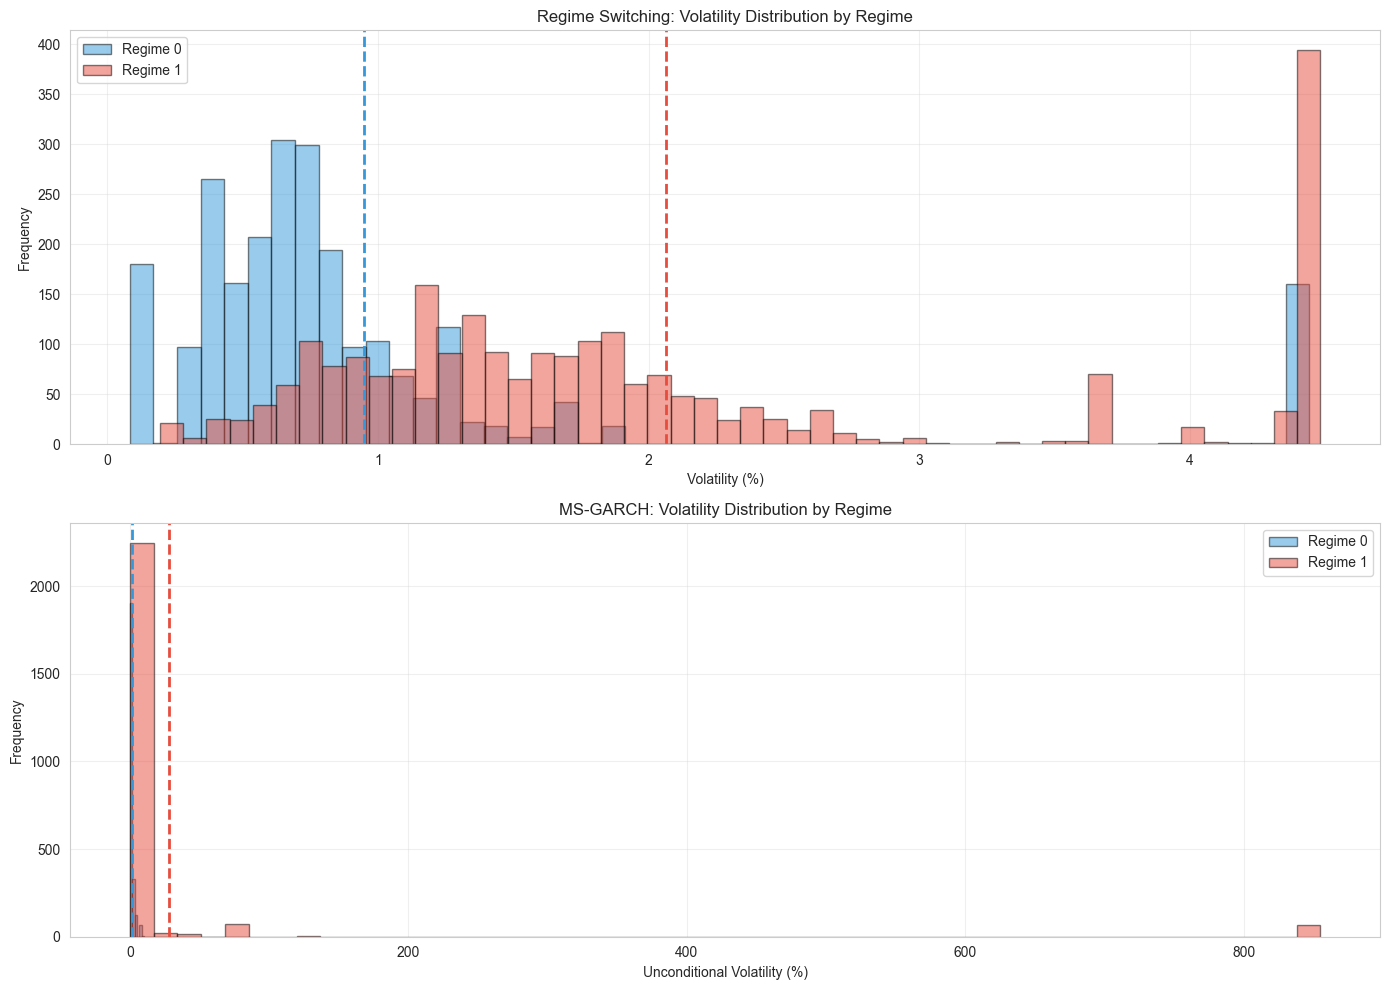

In [13]:
# Volatility distributions
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
axes[0].hist(rs_params['regime_0_vol']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[0].hist(rs_params['regime_1_vol']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[0].axvline(rs_params['regime_0_vol'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[0].axvline(rs_params['regime_1_vol'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_xlabel('Volatility (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Regime Switching: Volatility Distribution by Regime')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
axes[1].hist(ms_garch['uncond_vol_0']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[1].hist(ms_garch['uncond_vol_1']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[1].axvline(ms_garch['uncond_vol_0'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[1].axvline(ms_garch['uncond_vol_1'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[1].set_xlabel('Unconditional Volatility (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MS-GARCH: Volatility Distribution by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Transition Probability Analysis

In [14]:
# Analyze transition probabilities
print('='*80)
print('REGIME SWITCHING - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {rs_params['transition_prob_00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {rs_params['transition_prob_01'].mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {rs_params['transition_prob_10'].mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {rs_params['transition_prob_11'].mean():.4f}")

print('\n' + '='*80)
print('MS-GARCH - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {ms_garch['p00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {(1 - ms_garch['p00']).mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {(1 - ms_garch['p11']).mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {ms_garch['p11'].mean():.4f}")

REGIME SWITCHING - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.9404
P(switch to Regime 1 | in Regime 0): 0.0596
P(switch to Regime 0 | in Regime 1): 0.0560
P(stay in Regime 1 | in Regime 1): 0.9440

MS-GARCH - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.8391
P(switch to Regime 1 | in Regime 0): 0.1609
P(switch to Regime 0 | in Regime 1): 0.0951
P(stay in Regime 1 | in Regime 1): 0.9049


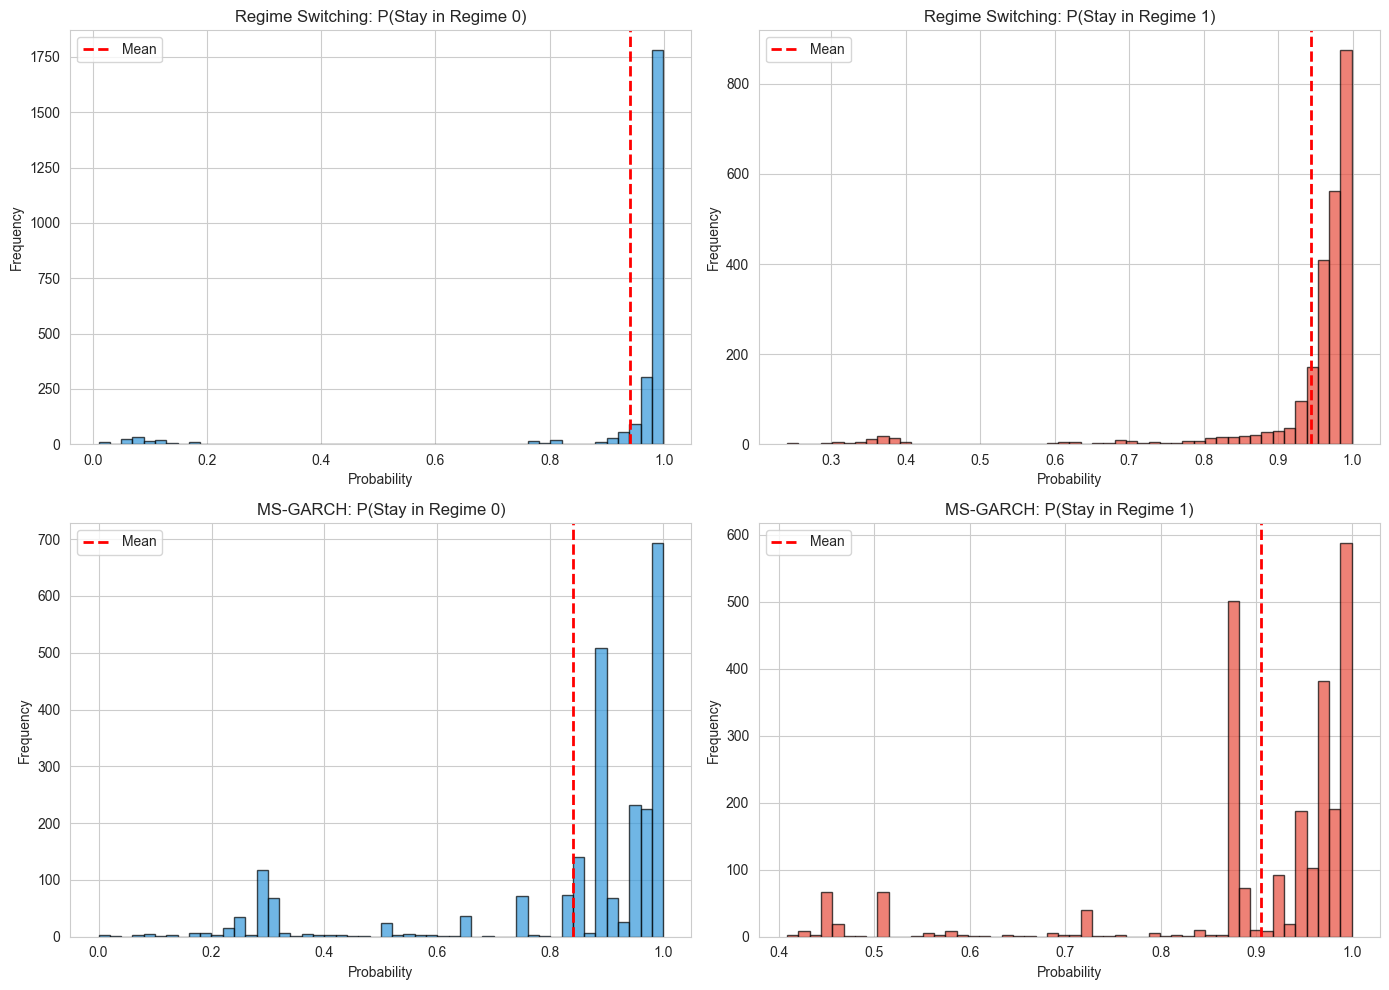

In [15]:
# Visualize transition probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime Switching - Persistence
axes[0, 0].hist(rs_params['transition_prob_00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_params['transition_prob_00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: P(Stay in Regime 0)')
axes[0, 0].legend()

axes[0, 1].hist(rs_params['transition_prob_11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_params['transition_prob_11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: P(Stay in Regime 1)')
axes[0, 1].legend()

# MS-GARCH - Persistence
axes[1, 0].hist(ms_garch['p00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_garch['p00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: P(Stay in Regime 0)')
axes[1, 0].legend()

axes[1, 1].hist(ms_garch['p11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_garch['p11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: P(Stay in Regime 1)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

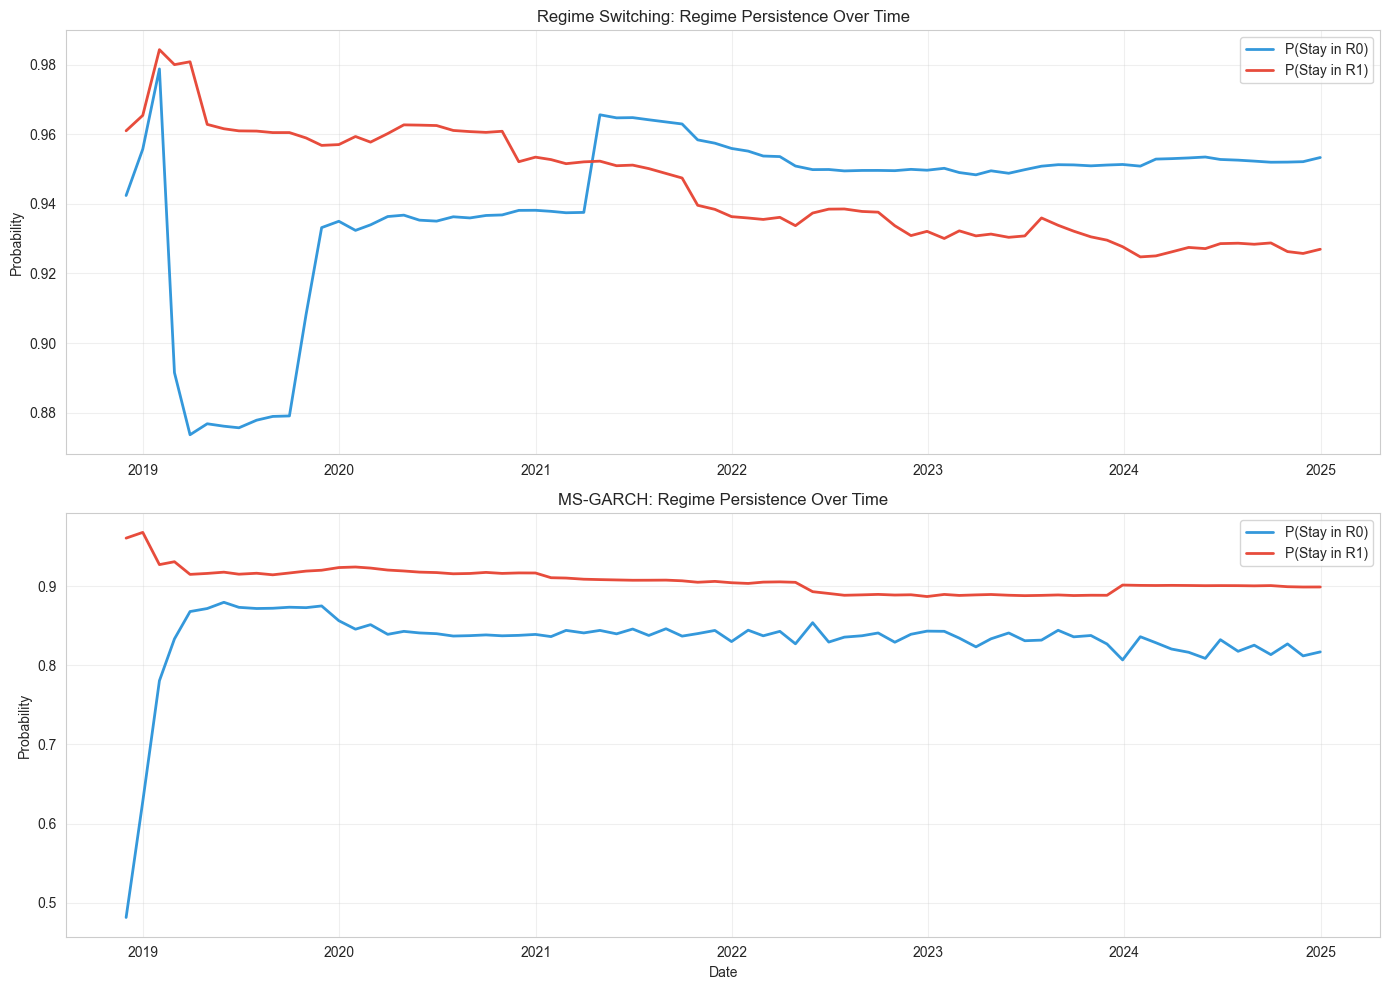

In [16]:
# Transition probabilities over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
rs_trans_time = rs_params.groupby('date')[['transition_prob_00', 'transition_prob_11']].mean()
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Persistence Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
ms_trans_time = ms_garch.groupby('date')[['p00', 'p11']].mean()
axes[1].plot(ms_trans_time.index, ms_trans_time['p00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[1].plot(ms_trans_time.index, ms_trans_time['p11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Persistence Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Time Series Visualization of Regimes

Let's look at a specific company over time.

In [17]:
# Select a company to analyze
sample_gvkey = rs_params['gvkey'].iloc[0]
print(f"Analyzing company: {sample_gvkey}")

# Filter data for this company
rs_company = rs_params[rs_params['gvkey'] == sample_gvkey].sort_values('date')
ms_company = ms_garch[ms_garch['gvkey'] == sample_gvkey].sort_values('date')

Analyzing company: 14447


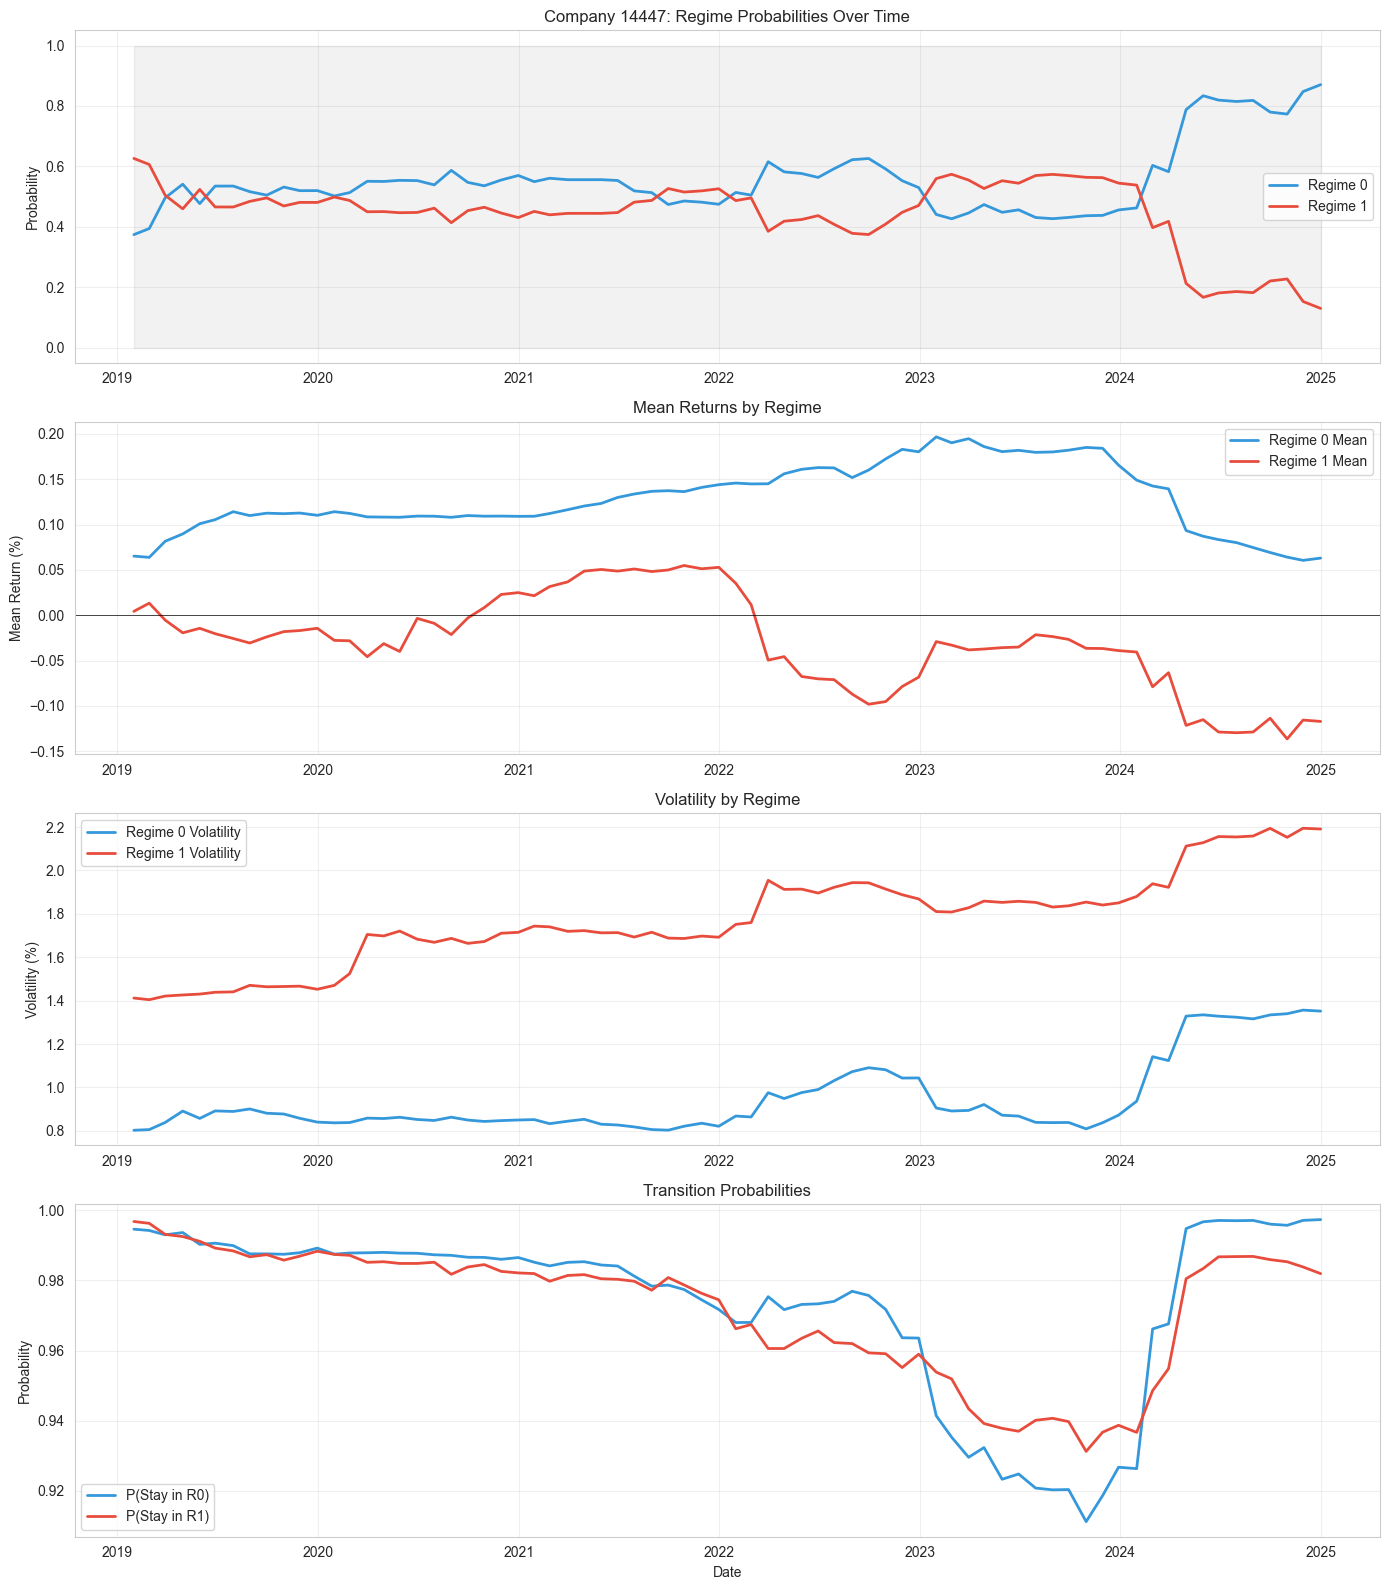

In [18]:
# Plot regime probabilities and parameters over time
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Regime probabilities
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_company['date'], 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Company {sample_gvkey}: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean returns by regime
axes[1].plot(rs_company['date'], rs_company['regime_0_mean']*100, label='Regime 0 Mean', color='#3498db', linewidth=2)
axes[1].plot(rs_company['date'], rs_company['regime_1_mean']*100, label='Regime 1 Mean', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('Mean Returns by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility by regime
axes[2].plot(rs_company['date'], rs_company['regime_0_vol']*100, label='Regime 0 Volatility', color='#3498db', linewidth=2)
axes[2].plot(rs_company['date'], rs_company['regime_1_vol']*100, label='Regime 1 Volatility', color='#e74c3c', linewidth=2)
axes[2].set_ylabel('Volatility (%)')
axes[2].set_title('Volatility by Regime')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Transition probabilities
axes[3].plot(rs_company['date'], rs_company['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[3].plot(rs_company['date'], rs_company['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[3].set_ylabel('Probability')
axes[3].set_xlabel('Date')
axes[3].set_title('Transition Probabilities')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Statistical Tests for Regime Differences

In [19]:
# Perform t-tests to check if regime parameters are significantly different
from scipy.stats import ttest_rel, ttest_ind

print('='*80)
print('REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(rs_params['regime_0_mean'], rs_params['regime_1_mean'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test volatility
t_stat, p_value = ttest_rel(rs_params['regime_0_vol'], rs_params['regime_1_vol'])
print(f"\nVolatility:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test degrees of freedom
t_stat, p_value = ttest_rel(rs_params['regime_0_nu'], rs_params['regime_1_nu'])
print(f"\nDegrees of Freedom (nu):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

print('\n' + '='*80)
print('MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(ms_garch['mu_0'], ms_garch['mu_1'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test GARCH parameters
t_stat, p_value = ttest_rel(ms_garch['alpha_0'], ms_garch['alpha_1'])
print(f"\nAlpha (ARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

t_stat, p_value = ttest_rel(ms_garch['beta_0'], ms_garch['beta_1'])
print(f"\nBeta (GARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: 3.2555
  p-value: 1.1477e-03
  Significant at 5% level: Yes

Volatility:
  t-statistic: -50.7628
  p-value: 0.0000e+00
  Significant at 5% level: Yes

Degrees of Freedom (nu):
  t-statistic: -1.9941
  p-value: 4.6249e-02
  Significant at 5% level: Yes

MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: -11.4169
  p-value: 1.9200e-29
  Significant at 5% level: Yes

Alpha (ARCH effect):
  t-statistic: -11.4518
  p-value: 1.3110e-29
  Significant at 5% level: Yes

Beta (GARCH effect):
  t-statistic: 0.8690
  p-value: 3.8496e-01
  Significant at 5% level: No


In [20]:
# Effect sizes (Cohen's d)
def cohens_d(x, y):
    """Calculate Cohen's d for effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

print('='*80)
print('EFFECT SIZES (Cohen\'s d)')
print('='*80)
print("\nRegime Switching:")
print(f"  Mean Returns: d = {cohens_d(rs_params['regime_0_mean'], rs_params['regime_1_mean']):.4f}")
print(f"  Volatility: d = {cohens_d(rs_params['regime_0_vol'], rs_params['regime_1_vol']):.4f}")
print(f"  Degrees of Freedom: d = {cohens_d(rs_params['regime_0_nu'], rs_params['regime_1_nu']):.4f}")

print("\nMS-GARCH:")
print(f"  Mean Returns: d = {cohens_d(ms_garch['mu_0'], ms_garch['mu_1']):.4f}")
print(f"  Alpha: d = {cohens_d(ms_garch['alpha_0'], ms_garch['alpha_1']):.4f}")
print(f"  Beta: d = {cohens_d(ms_garch['beta_0'], ms_garch['beta_1']):.4f}")

print("\nInterpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect")

EFFECT SIZES (Cohen's d)

Regime Switching:
  Mean Returns: d = 0.0963
  Volatility: d = -0.9658
  Degrees of Freedom: d = -0.0576

MS-GARCH:
  Mean Returns: d = -0.3248
  Alpha: d = -0.3504
  Beta: d = 0.0230

Interpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect


## 10. Cross-Sectional Analysis Across Companies

In [21]:
# Compare characteristics across companies
company_stats_rs = rs_params.groupby('gvkey').agg({
    'regime_0_mean': 'mean',
    'regime_1_mean': 'mean',
    'regime_0_vol': 'mean',
    'regime_1_vol': 'mean',
    'steady_state_regime_0': 'mean',
    'steady_state_regime_1': 'mean',
    'duration_regime_0': 'mean',
    'duration_regime_1': 'mean'
}).reset_index()

# Add volatility ratio
company_stats_rs['vol_ratio'] = company_stats_rs['regime_1_vol'] / company_stats_rs['regime_0_vol']

print('Company-Level Statistics (Regime Switching):')
display(company_stats_rs.head(10))

Company-Level Statistics (Regime Switching):


,gvkey,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,steady_state_regime_0,steady_state_regime_1,duration_regime_0,duration_regime_1,vol_ratio
0,14447,0.001287,-0.000298,0.009452,0.017733,0.554671,0.445329,88.054606,56.586646,1.876020
1,15532,-0.001327,-0.000203,0.040509,0.044817,0.502672,0.497328,92.974300,177.893303,1.106351
2,15549,0.000483,-0.000402,0.004060,0.044817,0.389674,0.610326,44.320833,387.393039,11.039917
3,15617,-0.001355,0.000549,0.034889,0.044629,0.382554,0.617446,349.483221,559.909100,1.279172
4,15677,0.000145,-0.000160,0.001249,0.005792,0.696103,0.303897,233.155009,96.355974,4.639140
5,15724,0.000081,-0.000122,0.001037,0.032410,0.789002,0.210998,140.010902,40.669886,31.243238
6,16348,-0.005602,-0.000073,0.030294,0.044604,0.601004,0.398996,244.606325,261.465026,1.472347
7,17436,0.000046,-0.000623,0.007942,0.015840,0.814751,0.185249,408.144918,109.565907,1.994389
8,17452,0.000229,-0.000680,0.006714,0.012604,0.804102,0.195898,171.470747,49.172644,1.877450
9,19349,0.000331,-0.000100,0.006649,0.011730,0.580972,0.419028,302.879561,317.362248,1.764131


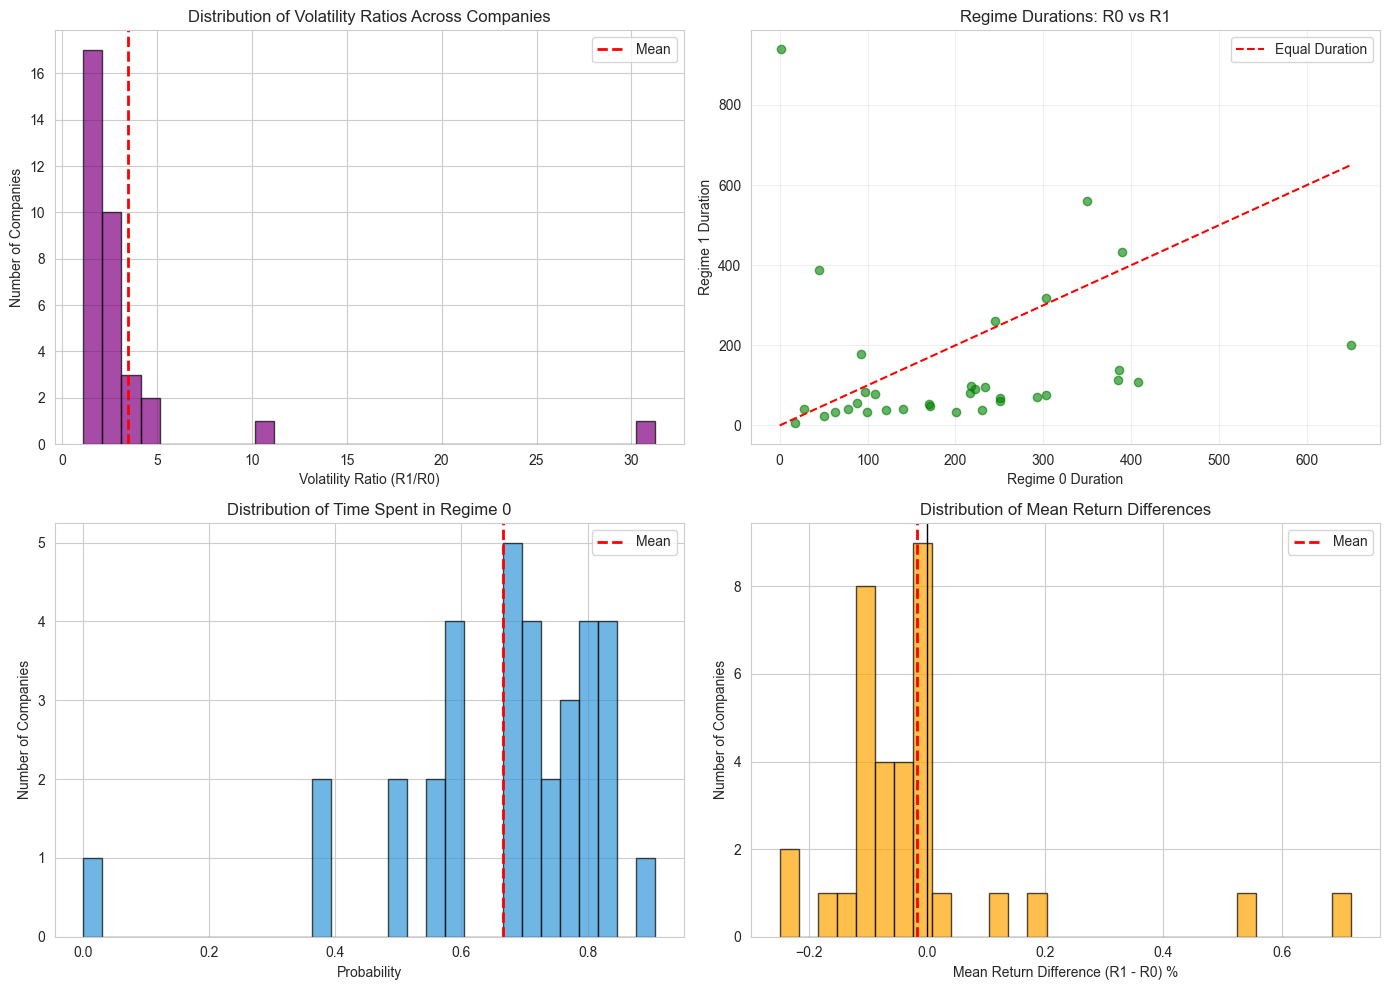

In [22]:
# Visualize company-level differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Volatility ratio across companies
axes[0, 0].hist(company_stats_rs['vol_ratio'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(company_stats_rs['vol_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Volatility Ratio (R1/R0)')
axes[0, 0].set_ylabel('Number of Companies')
axes[0, 0].set_title('Distribution of Volatility Ratios Across Companies')
axes[0, 0].legend()

# Duration comparison
axes[0, 1].scatter(company_stats_rs['duration_regime_0'], company_stats_rs['duration_regime_1'], alpha=0.6, color='green')
axes[0, 1].plot([0, company_stats_rs['duration_regime_0'].max()], [0, company_stats_rs['duration_regime_0'].max()], 'r--', label='Equal Duration')
axes[0, 1].set_xlabel('Regime 0 Duration')
axes[0, 1].set_ylabel('Regime 1 Duration')
axes[0, 1].set_title('Regime Durations: R0 vs R1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Regime frequency
axes[1, 0].hist(company_stats_rs['steady_state_regime_0'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(company_stats_rs['steady_state_regime_0'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Number of Companies')
axes[1, 0].set_title('Distribution of Time Spent in Regime 0')
axes[1, 0].legend()

# Mean return difference
company_stats_rs['mean_diff'] = company_stats_rs['regime_1_mean'] - company_stats_rs['regime_0_mean']
axes[1, 1].hist(company_stats_rs['mean_diff']*100, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(company_stats_rs['mean_diff'].mean()*100, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Mean Return Difference (R1 - R0) %')
axes[1, 1].set_ylabel('Number of Companies')
axes[1, 1].set_title('Distribution of Mean Return Differences')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Summary of key findings
print('='*80)
print('KEY FINDINGS SUMMARY')
print('='*80)

print('\n1. REGIME FREQUENCY:')
print(f"   - Average time in Regime 0 (RS): {rs_params['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (RS): {rs_params['steady_state_regime_1'].mean():.2%}")
print(f"   - Average time in Regime 0 (MS-GARCH): {ms_garch['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (MS-GARCH): {ms_garch['steady_state_regime_1'].mean():.2%}")

print('\n2. REGIME PERSISTENCE:')
print(f"   - Regime 0 expected duration (RS): {rs_params['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (RS): {rs_params['duration_regime_1'].mean():.2f} periods")
print(f"   - Regime 0 expected duration (MS-GARCH): {ms_garch['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (MS-GARCH): {ms_garch['duration_regime_1'].mean():.2f} periods")

print('\n3. PARAMETER DIFFERENCES:')
print(f"   - Mean return difference (RS): {(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%")
print(f"   - Volatility ratio (RS): {(rs_params['regime_1_vol'].mean() / rs_params['regime_0_vol'].mean()):.2f}x")
print(f"   - Mean return difference (MS-GARCH): {(ms_garch['mu_1'].mean() - ms_garch['mu_0'].mean())*100:.4f}%")

print('\n4. CROSS-SECTIONAL VARIATION:')
print(f"   - Volatility ratio std dev: {company_stats_rs['vol_ratio'].std():.2f}")
print(f"   - Companies with higher vol in R1: {(company_stats_rs['vol_ratio'] > 1).sum()} / {len(company_stats_rs)}")
print(f"   - Companies with positive mean diff: {(company_stats_rs['mean_diff'] > 0).sum()} / {len(company_stats_rs)}")

print('\n' + '='*80)

KEY FINDINGS SUMMARY

1. REGIME FREQUENCY:
   - Average time in Regime 0 (RS): 66.68%
   - Average time in Regime 1 (RS): 33.32%
   - Average time in Regime 0 (MS-GARCH): 46.72%
   - Average time in Regime 1 (MS-GARCH): 53.28%

2. REGIME PERSISTENCE:
   - Regime 0 expected duration (RS): 203.26 periods
   - Regime 1 expected duration (RS): 144.67 periods
   - Regime 0 expected duration (MS-GARCH): 60.43 periods
   - Regime 1 expected duration (MS-GARCH): 113.92 periods

3. PARAMETER DIFFERENCES:
   - Mean return difference (RS): -0.0166%
   - Volatility ratio (RS): 2.17x
   - Mean return difference (MS-GARCH): 0.2853%

4. CROSS-SECTIONAL VARIATION:
   - Volatility ratio std dev: 5.19
   - Companies with higher vol in R1: 34 / 34
   - Companies with positive mean diff: 6 / 34



## 11. Leverage Group Analysis

Analyze regime switching and MS-GARCH parameters across different leverage groups.
This helps understand if regime dynamics differ between high-leverage and low-leverage firms.

In [24]:
# Load merged data to get leverage information
df_merged = pd.read_csv('data/output/merged_data_with_merton.csv')
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Calculate leverage ratio
df_merged['leverage_ratio'] = df_merged['liabilities_total'] / (df_merged['liabilities_total'] + df_merged['mkt_cap'])

# Calculate average leverage for each firm
firm_leverage = df_merged.groupby('gvkey').agg({
    'leverage_ratio': 'mean',
    'company': 'first'
}).reset_index()

firm_leverage.columns = ['gvkey', 'avg_leverage', 'company']

# Create leverage terciles
firm_leverage['leverage_tercile'] = pd.qcut(
    firm_leverage['avg_leverage'], 
    q=3, 
    labels=['Low Leverage', 'Mid Leverage', 'High Leverage']
)

# Get tercile boundaries
tercile_boundaries = pd.qcut(firm_leverage['avg_leverage'], q=3, retbins=True)[1]

print("Leverage Group Definitions:")
print(f"Low Leverage:  < {tercile_boundaries[1]:.2%}")
print(f"Mid Leverage:  {tercile_boundaries[1]:.2%} - {tercile_boundaries[2]:.2%}")
print(f"High Leverage: > {tercile_boundaries[2]:.2%}")

# Create leverage mapping dictionary
leverage_group_map = firm_leverage.set_index('gvkey')['leverage_tercile'].to_dict()

# Add leverage groups to regime parameter dataframes
rs_params['leverage_tercile'] = rs_params['gvkey'].map(leverage_group_map)
ms_garch['leverage_tercile'] = ms_garch['gvkey'].map(leverage_group_map)

print(f"\n✓ Leverage groups assigned")
print(f"  Low Leverage: {(rs_params['leverage_tercile'] == 'Low Leverage').sum()} observations")
print(f"  Mid Leverage: {(rs_params['leverage_tercile'] == 'Mid Leverage').sum()} observations")
print(f"  High Leverage: {(rs_params['leverage_tercile'] == 'High Leverage').sum()} observations")

Leverage Group Definitions:
Low Leverage:  < 41.85%
Mid Leverage:  41.85% - 62.42%
High Leverage: > 62.42%

✓ Leverage groups assigned
  Low Leverage: 859 observations
  Mid Leverage: 785 observations
  High Leverage: 780 observations


In [25]:
# Regime frequency by leverage group
print('='*80)
print('REGIME FREQUENCY BY LEVERAGE GROUP')
print('='*80)

for model_name, df, col_prefix in [('Regime Switching', rs_params, 'steady_state_regime_'), 
                                     ('MS-GARCH', ms_garch, 'steady_state_regime_')]:
    print(f"\n{model_name}:")
    print(f"{'-'*80}")
    
    for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
        group_data = df[df['leverage_tercile'] == leverage_group]
        regime_0_prob = group_data[f'{col_prefix}0'].mean()
        regime_1_prob = group_data[f'{col_prefix}1'].mean()
        
        print(f"\n  {leverage_group}:")
        print(f"    Regime 0: {regime_0_prob:.2%}")
        print(f"    Regime 1: {regime_1_prob:.2%}")

REGIME FREQUENCY BY LEVERAGE GROUP

Regime Switching:
--------------------------------------------------------------------------------

  Low Leverage:
    Regime 0: 72.17%
    Regime 1: 27.83%

  Mid Leverage:
    Regime 0: 70.49%
    Regime 1: 29.51%

  High Leverage:
    Regime 0: 56.82%
    Regime 1: 43.18%

MS-GARCH:
--------------------------------------------------------------------------------

  Low Leverage:
    Regime 0: 38.82%
    Regime 1: 61.18%

  Mid Leverage:
    Regime 0: 47.21%
    Regime 1: 52.79%

  High Leverage:
    Regime 0: 54.91%
    Regime 1: 45.09%


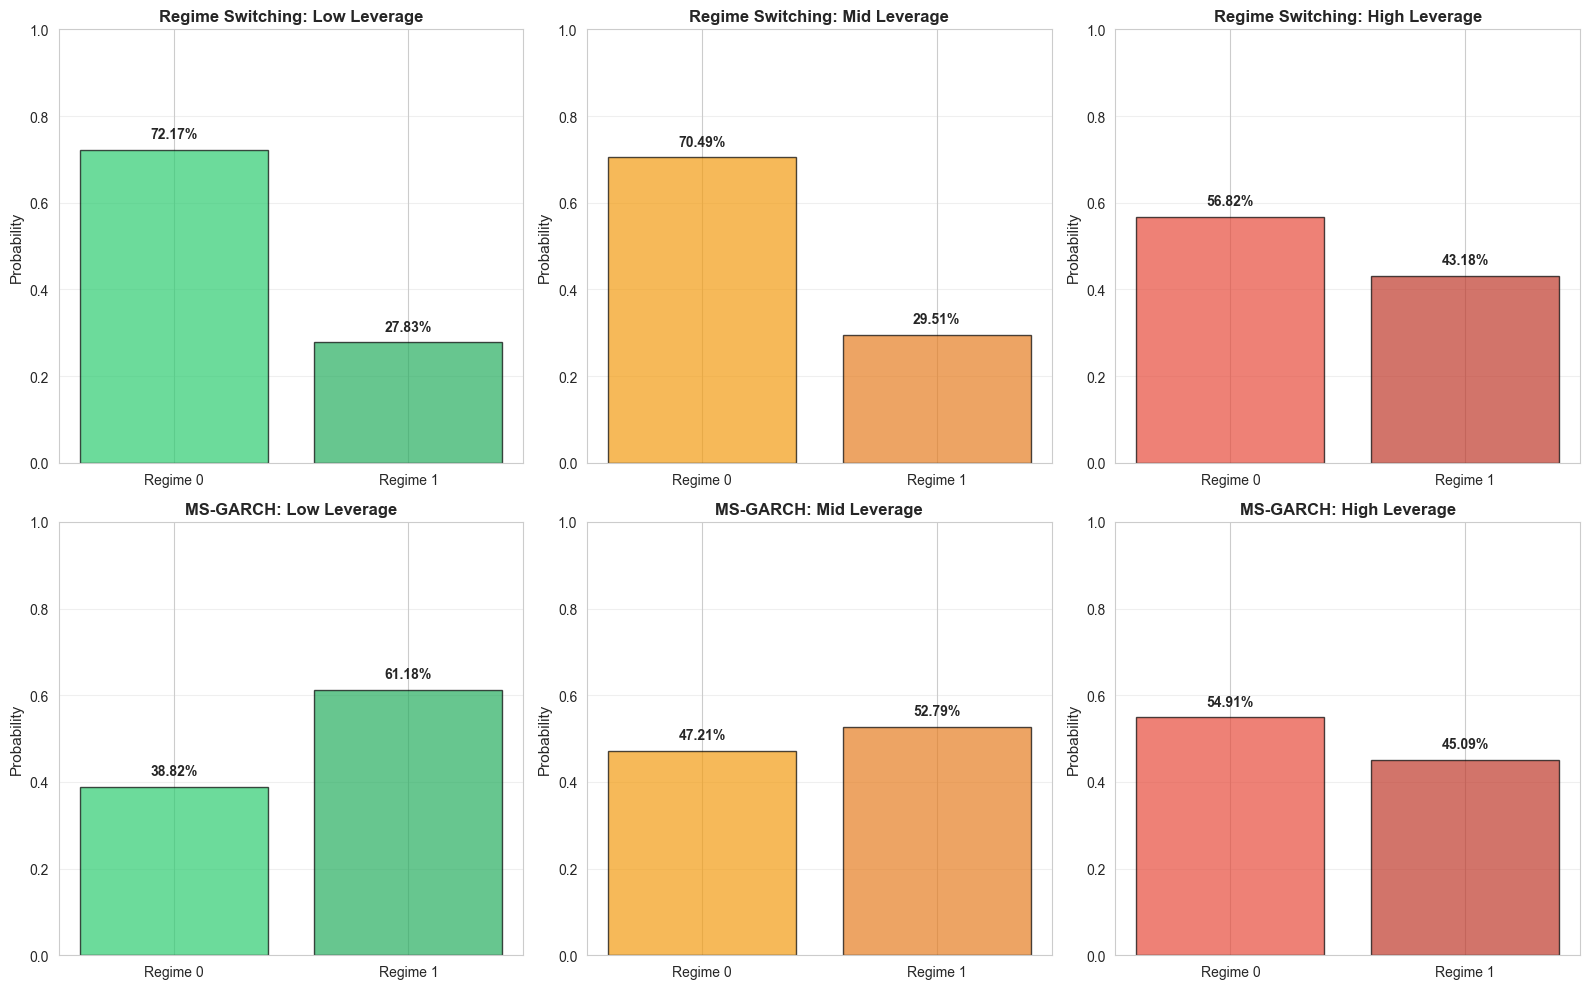

In [26]:
# Visualize regime frequency by leverage group
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors_r0 = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
colors_r1 = ['#27ae60', '#e67e22', '#c0392b']  # Darker shades

# Regime Switching
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[0, idx]
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'Regime Switching: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# MS-GARCH
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[1, idx]
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'MS-GARCH: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [27]:
# Parameter comparison by leverage group - Regime Switching
print('='*80)
print('REGIME SWITCHING: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

rs_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    rs_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['regime_0_mean'].mean() * 100,
        'Mean R1 (%)': group_data['regime_1_mean'].mean() * 100,
        'Vol R0 (%)': group_data['regime_0_vol'].mean() * 100,
        'Vol R1 (%)': group_data['regime_1_vol'].mean() * 100,
        'Vol Ratio': group_data['regime_1_vol'].mean() / group_data['regime_0_vol'].mean(),
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

rs_leverage_df = pd.DataFrame(rs_leverage_summary)
display(rs_leverage_df.round(4))

REGIME SWITCHING: PARAMETER COMPARISON BY LEVERAGE GROUP


,Leverage Group,Mean R0 (%),Mean R1 (%),Vol R0 (%),Vol R1 (%),Vol Ratio,Duration R0,Duration R1,P(R0),P(R1)
0,Low Leverage,0.0641,-0.0261,0.9678,1.9282,1.9925,192.0803,64.0438,0.7217,0.2783
1,Mid Leverage,0.0253,-0.0524,0.6122,1.4986,2.4478,161.8337,80.8485,0.7049,0.2951
2,High Leverage,-0.1291,-0.0032,1.2656,2.7783,2.1953,257.2658,297.7032,0.5682,0.4318


In [28]:
# Parameter comparison by leverage group - MS-GARCH
print('='*80)
print('MS-GARCH: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

ms_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    ms_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['mu_0'].mean() * 100,
        'Mean R1 (%)': group_data['mu_1'].mean() * 100,
        'Omega R0': group_data['omega_0'].mean(),
        'Omega R1': group_data['omega_1'].mean(),
        'Alpha R0': group_data['alpha_0'].mean(),
        'Alpha R1': group_data['alpha_1'].mean(),
        'Beta R0': group_data['beta_0'].mean(),
        'Beta R1': group_data['beta_1'].mean(),
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

ms_leverage_df = pd.DataFrame(ms_leverage_summary)
display(ms_leverage_df.round(6))

MS-GARCH: PARAMETER COMPARISON BY LEVERAGE GROUP


,Leverage Group,Mean R0 (%),Mean R1 (%),Omega R0,Omega R1,Alpha R0,Alpha R1,Beta R0,Beta R1,Duration R0,Duration R1,P(R0),P(R1)
0,Low Leverage,-0.011713,0.079725,0.000004,0.000013,0.036673,0.124421,0.686835,0.707329,47.628887,65.788893,0.388232,0.611768
1,Mid Leverage,-0.586540,0.030136,0.000006,0.000711,0.083007,0.108200,0.632071,0.634471,38.237661,210.187494,0.472128,0.527872
2,High Leverage,0.000577,0.165753,0.000678,0.012553,0.099004,0.120608,0.539583,0.487827,96.847762,70.051273,0.549125,0.450875


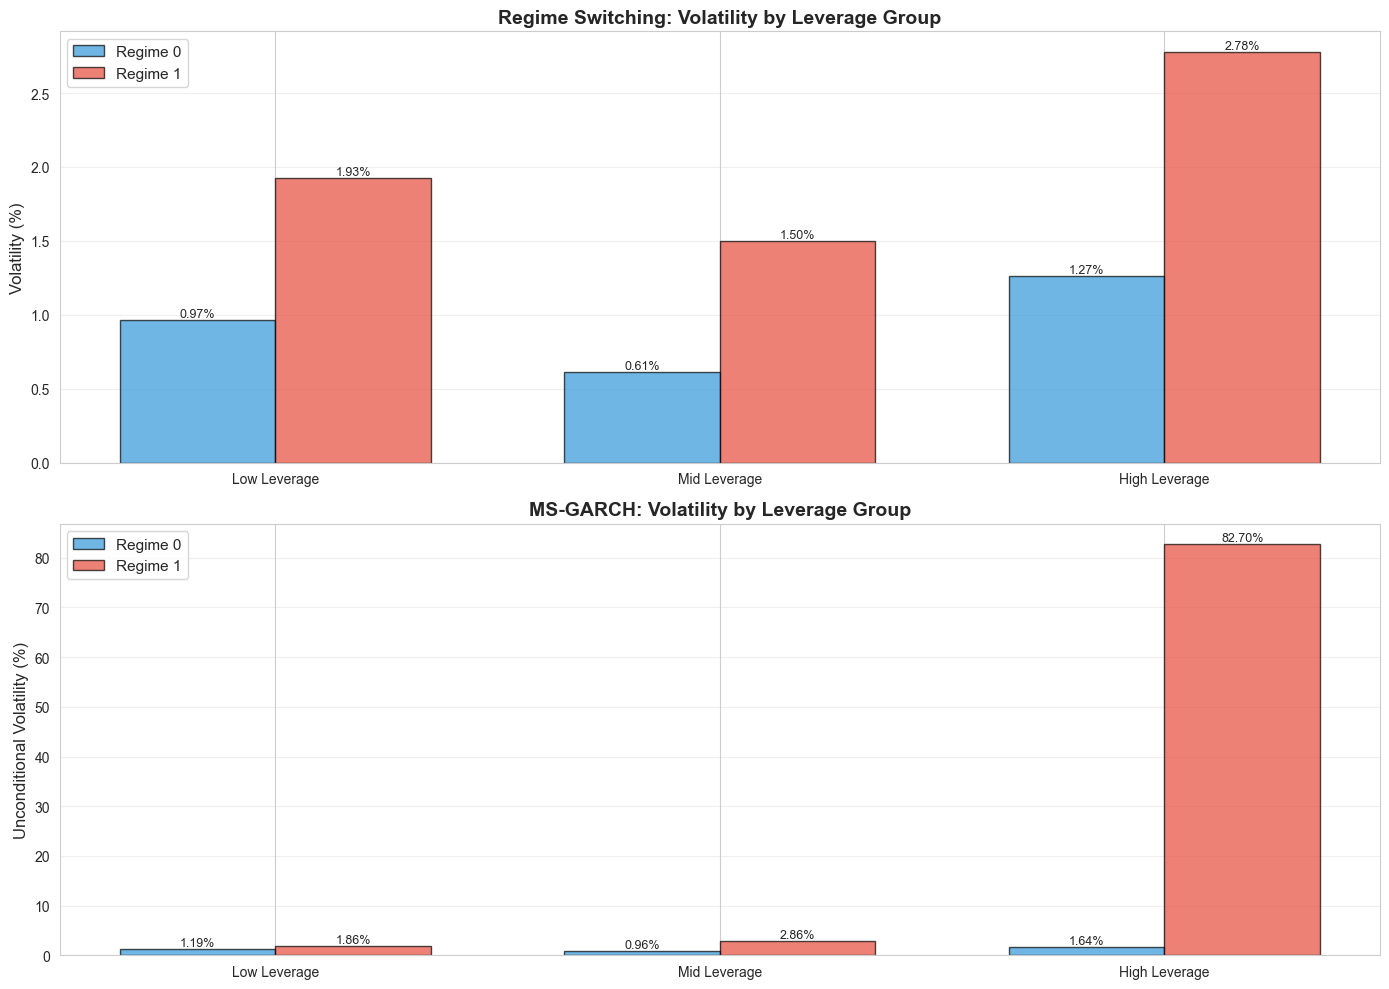

In [29]:
# Visualize volatility by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Regime Switching
ax = axes[0]
x = np.arange(len(leverage_groups))
width = 0.35

r0_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_0_vol'].mean() * 100 
           for lg in leverage_groups]
r1_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_1_vol'].mean() * 100 
           for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Volatility (%)', fontsize=12)
ax.set_title('Regime Switching: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_0'].mean() * 100 
              for lg in leverage_groups]
r1_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_1'].mean() * 100 
              for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Unconditional Volatility (%)', fontsize=12)
ax.set_title('MS-GARCH: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

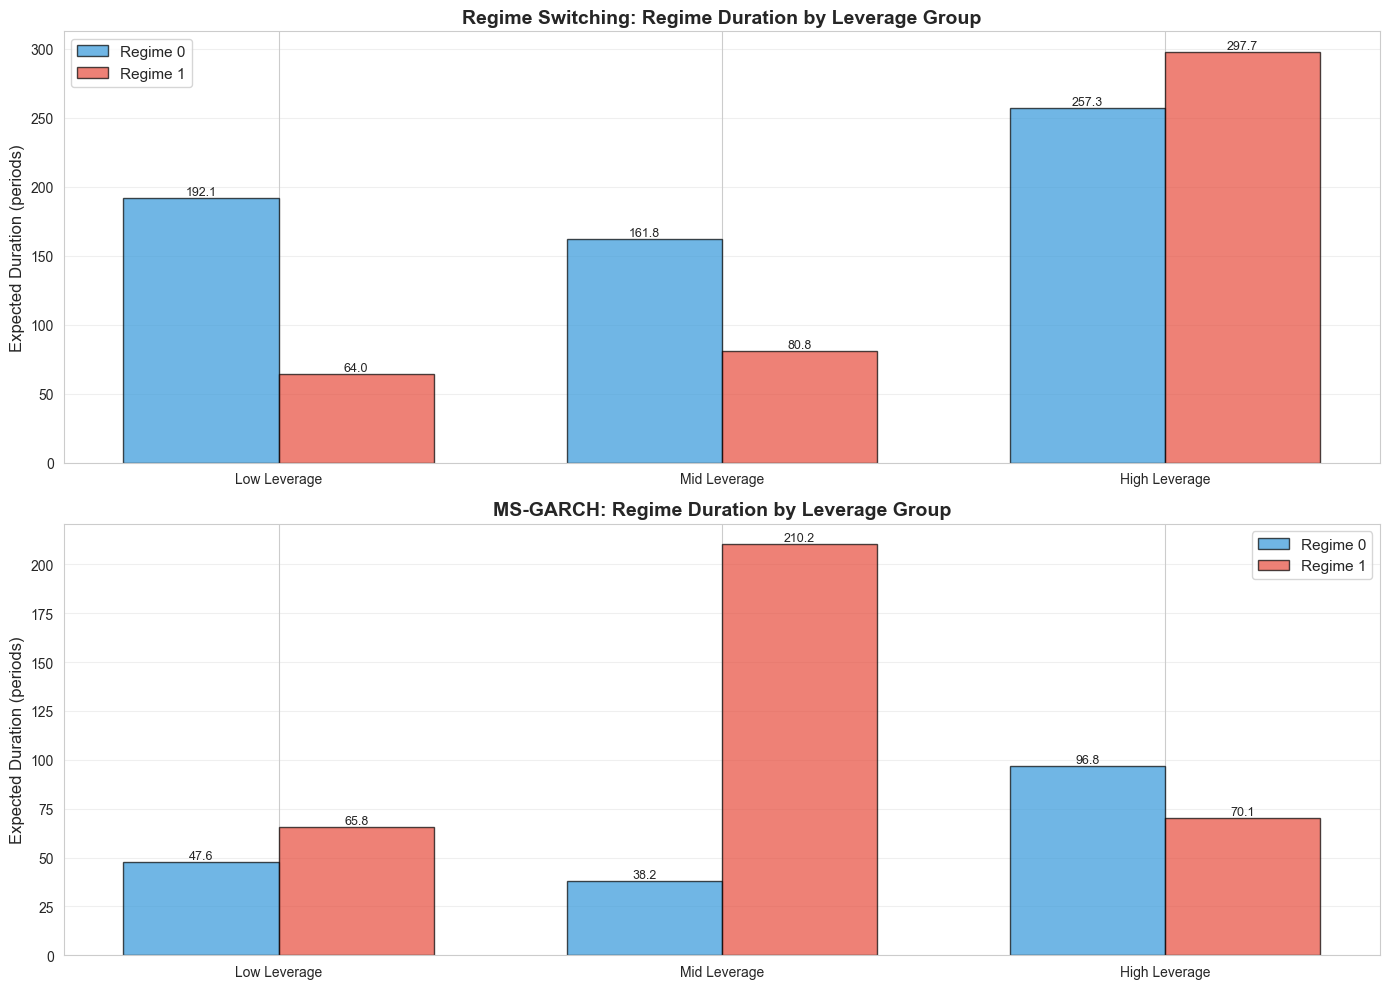

In [30]:
# Visualize regime duration by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
x = np.arange(len(leverage_groups))
width = 0.35

# Regime Switching
ax = axes[0]
r0_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                for lg in leverage_groups]
r1_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('Regime Switching: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                   for lg in leverage_groups]
r1_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                   for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('MS-GARCH: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

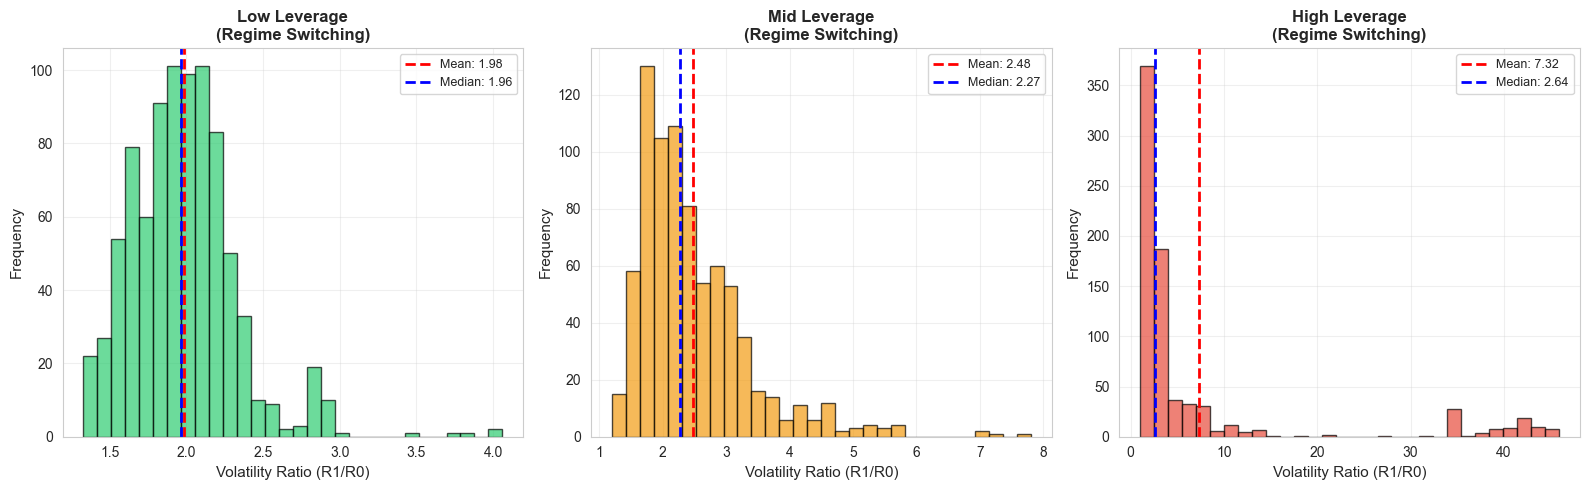

Volatility Ratio Summary by Leverage Group (Regime Switching):

Low Leverage:
  Mean:   1.9825
  Median: 1.9625
  Std:    0.3475
  Min:    1.3294
  Max:    4.0611

Mid Leverage:
  Mean:   2.4797
  Median: 2.2683
  Std:    0.8839
  Min:    1.1964
  Max:    7.8012

High Leverage:
  Mean:   7.3153
  Median: 2.6357
  Std:    11.8375
  Min:    1.0094
  Max:    45.9244


In [31]:
# Distribution of volatility ratios by leverage group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[idx]
    
    # Get volatility ratio for this group (Regime Switching)
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    ax.hist(vol_ratios, bins=30, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axvline(vol_ratios.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {vol_ratios.mean():.2f}')
    ax.axvline(vol_ratios.median(), color='blue', linestyle='--', linewidth=2, 
               label=f'Median: {vol_ratios.median():.2f}')
    
    ax.set_xlabel('Volatility Ratio (R1/R0)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{leverage_group}\n(Regime Switching)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print('Volatility Ratio Summary by Leverage Group (Regime Switching):')
print('='*80)
for leverage_group in leverage_groups:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    print(f"\n{leverage_group}:")
    print(f"  Mean:   {vol_ratios.mean():.4f}")
    print(f"  Median: {vol_ratios.median():.4f}")
    print(f"  Std:    {vol_ratios.std():.4f}")
    print(f"  Min:    {vol_ratios.min():.4f}")
    print(f"  Max:    {vol_ratios.max():.4f}")

In [32]:
# Summary of leverage group findings
print('='*80)
print('LEVERAGE GROUP ANALYSIS - KEY FINDINGS')
print('='*80)

print('\n1. REGIME FREQUENCY BY LEVERAGE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    ms_group = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    RS - Regime 0: {rs_group['steady_state_regime_0'].mean():.2%}, Regime 1: {rs_group['steady_state_regime_1'].mean():.2%}")
    print(f"    MS - Regime 0: {ms_group['steady_state_regime_0'].mean():.2%}, Regime 1: {ms_group['steady_state_regime_1'].mean():.2%}")

print('\n2. VOLATILITY PATTERNS:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratio = rs_group['regime_1_vol'].mean() / rs_group['regime_0_vol'].mean()
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Vol: {rs_group['regime_0_vol'].mean()*100:.2f}%")
    print(f"    Regime 1 Vol: {rs_group['regime_1_vol'].mean()*100:.2f}%")
    print(f"    Volatility Ratio: {vol_ratio:.2f}x")

print('\n3. REGIME PERSISTENCE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Duration: {rs_group['duration_regime_0'].mean():.1f} periods")
    print(f"    Regime 1 Duration: {rs_group['duration_regime_1'].mean():.1f} periods")

print('\n4. INTERPRETATION:')
print('  - High leverage firms may show different regime dynamics')
print('  - Volatility patterns may vary by capital structure')
print('  - Regime persistence could differ across leverage groups')
print('  - Consider leverage when interpreting regime-switching behavior')

print('\n' + '='*80)

LEVERAGE GROUP ANALYSIS - KEY FINDINGS

1. REGIME FREQUENCY BY LEVERAGE:

  Low Leverage:
    RS - Regime 0: 72.17%, Regime 1: 27.83%
    MS - Regime 0: 38.82%, Regime 1: 61.18%

  Mid Leverage:
    RS - Regime 0: 70.49%, Regime 1: 29.51%
    MS - Regime 0: 47.21%, Regime 1: 52.79%

  High Leverage:
    RS - Regime 0: 56.82%, Regime 1: 43.18%
    MS - Regime 0: 54.91%, Regime 1: 45.09%

2. VOLATILITY PATTERNS:

  Low Leverage:
    Regime 0 Vol: 0.97%
    Regime 1 Vol: 1.93%
    Volatility Ratio: 1.99x

  Mid Leverage:
    Regime 0 Vol: 0.61%
    Regime 1 Vol: 1.50%
    Volatility Ratio: 2.45x

  High Leverage:
    Regime 0 Vol: 1.27%
    Regime 1 Vol: 2.78%
    Volatility Ratio: 2.20x

3. REGIME PERSISTENCE:

  Low Leverage:
    Regime 0 Duration: 192.1 periods
    Regime 1 Duration: 64.0 periods

  Mid Leverage:
    Regime 0 Duration: 161.8 periods
    Regime 1 Duration: 80.8 periods

  High Leverage:
    Regime 0 Duration: 257.3 periods
    Regime 1 Duration: 297.7 periods

4. INTERP